# Load necessary libraries and read the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset Load
df = pd.read_csv("Price_Prediction.csv")

# Basic Overview
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


# Check data summary, missing values, and feature correlations

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

--- Summary Statistics ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population 

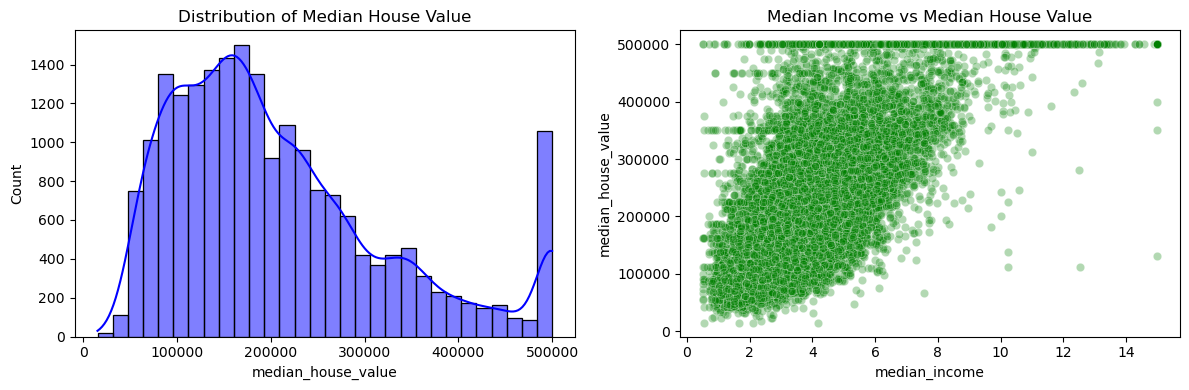

In [3]:
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

# Visualizing target variable (median_house_value) distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['median_house_value'], kde=True, bins=30, color='blue')
plt.title('Distribution of Median House Value')

# Visualizing relationship between median_income and median_house_value
plt.subplot(1, 2, 2)
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='green')
plt.title('Median Income vs Median House Value')
plt.tight_layout()
plt.show()

# Fill missing values, create new features, and encode categorical variables

In [16]:
# 1. Fill missing values in 'total_bedrooms' using median (Warning Fixed)
df_clean = df.copy()
df_clean['total_bedrooms'] = df_clean['total_bedrooms'].fillna(df_clean['total_bedrooms'].median())

# 2. Feature Engineering (Ratio-based features)
df_clean['rooms_per_household'] = df_clean['total_rooms'] / df_clean['households']
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population'] / df_clean['households']

# 3. One-Hot Encoding for 'ocean_proximity'
df_encoded = pd.get_dummies(df_clean, columns=['ocean_proximity'], drop_first=True)

print("Preprocessed Data Shape:", df_encoded.shape)
df_encoded.head()

Preprocessed Data Shape: (20640, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,6.281853,0.172096,2.181467,False,False,True,False


 # Train Simple Linear Regression using the strongest feature ('median_income') with the target variable

In [7]:
X_simple = df_encoded[['median_income']]
y = df_encoded['median_house_value']

# Train-Test Split (80% Train, 20% Test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Model Training
slr_model = LinearRegression()
slr_model.fit(X_train_s, y_train_s)

# Predictions & Metrics
y_pred_s = slr_model.predict(X_test_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"--- Simple Linear Regression Results ---")
print(f"Mean Squared Error (MSE) : {mse_s:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_s:.2f}")
print(f"R-squared (R2 Score)     : {r2_s:.4f}")

--- Simple Linear Regression Results ---
Mean Squared Error (MSE) : 7091157771.77
Root Mean Squared Error (RMSE): 84209.01
R-squared (R2 Score)     : 0.4589


# By using all independent features train  Multiple Linear Regression 

In [9]:
X_multi = df_encoded.drop(columns=['median_house_value'])

# Train-Test Split (80% Train, 20% Test)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Model Training
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)

# Predictions & Metrics
y_pred_m = mlr_model.predict(X_test_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"--- Multiple Linear Regression Results ---")
print(f"Mean Squared Error (MSE) : {mse_m:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_m:.2f}")
print(f"R-squared (R2 Score)     : {r2_m:.4f}")

--- Multiple Linear Regression Results ---
Mean Squared Error (MSE) : 5280716470.09
Root Mean Squared Error (RMSE): 72668.54
R-squared (R2 Score)     : 0.5970


# Comparison table show and  Actual vs Predicted visualization plot

--- Final Performance Summary ---
                     Model          MSE         RMSE  R-squared (R²)
  Simple Linear Regression 7.091158e+09 84209.012414        0.458859
Multiple Linear Regression 5.280716e+09 72668.538379        0.597018


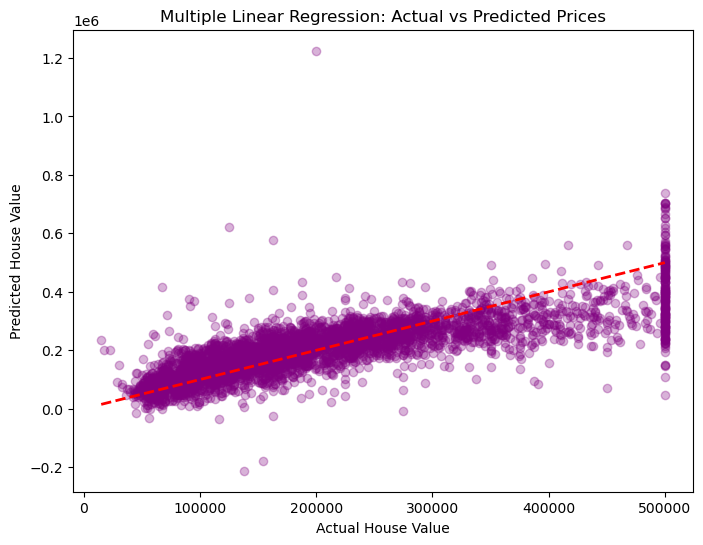

In [22]:
comparison_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MSE': [mse_s, mse_m],
    'RMSE': [rmse_s, rmse_m],
    'R-squared (R²)': [r2_s, r2_m]
})

print("--- Final Performance Summary ---")
print(comparison_df.to_string(index=False))

# Plotting Actual vs Predicted Prices for Multiple Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_m, alpha=0.3, color='purple')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Multiple Linear Regression: Actual vs Predicted Prices')
plt.show()